<a href="https://colab.research.google.com/github/martinafloresdarcais/IA2_AIDS/blob/main/aids_clinicaltrials.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AI2 Progetto AIDS dataset

In [1]:
# Installazioni
!pip install ucimlrepo --quiet

# Import librerie
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print("Setup completato.")

# Caricamento dataset
ds = fetch_ucirepo(id=890)

X = ds.data.features
y = ds.data.targets

print(ds.metadata['name'])
print(f"\nDimensioni X: {X.shape}")
print(f"Dimensioni y: {y.shape}")
print(f"\nFeature:\n{X.columns.tolist()}")
print(f"\nDistribuzione target:\n{y['cid'].value_counts()}")


Setup completato.
AIDS Clinical Trials Group Study 175

Dimensioni X: (2139, 23)
Dimensioni y: (2139, 1)

Feature:
['time', 'trt', 'age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'zprior', 'preanti', 'race', 'gender', 'str2', 'strat', 'symptom', 'treat', 'offtrt', 'cd40', 'cd420', 'cd80', 'cd820']

Distribuzione target:
cid
0    1618
1     521
Name: count, dtype: int64


In [2]:
# Prima esplorazione strutturata

# Uniamo X e y per esplorare insieme
df = X.copy()
df['cid'] = y['cid'].values

# Tipi di variabili e valori mancanti
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 24 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   time     2139 non-null   int64  
 1   trt      2139 non-null   int64  
 2   age      2139 non-null   int64  
 3   wtkg     2139 non-null   float64
 4   hemo     2139 non-null   int64  
 5   homo     2139 non-null   int64  
 6   drugs    2139 non-null   int64  
 7   karnof   2139 non-null   int64  
 8   oprior   2139 non-null   int64  
 9   z30      2139 non-null   int64  
 10  zprior   2139 non-null   int64  
 11  preanti  2139 non-null   int64  
 12  race     2139 non-null   int64  
 13  gender   2139 non-null   int64  
 14  str2     2139 non-null   int64  
 15  strat    2139 non-null   int64  
 16  symptom  2139 non-null   int64  
 17  treat    2139 non-null   int64  
 18  offtrt   2139 non-null   int64  
 19  cd40     2139 non-null   int64  
 20  cd420    2139 non-null   int64  
 21  cd80     2139 

In [3]:
# Statistiche descrittive
df.describe()


,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,cid
count,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,...,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000
mean,879.098177,1.520804,35.248247,75.125311,0.084151,0.661057,0.131370,95.446470,0.021973,0.550257,...,0.585788,1.979897,0.172978,0.751286,0.362786,350.501169,371.307153,986.627396,935.369799,0.243572
std,292.274324,1.127890,8.709026,13.263164,0.277680,0.473461,0.337883,5.900985,0.146629,0.497584,...,0.492701,0.899053,0.378317,0.432369,0.480916,118.573863,144.634909,480.197750,444.976051,0.429338
min,14.000000,0.000000,12.000000,31.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,49.000000,40.000000,124.000000,0.000000
25%,727.000000,1.000000,29.000000,66.679200,0.000000,0.000000,0.000000,90.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,263.500000,269.000000,654.000000,631.500000,0.000000
50%,997.000000,2.000000,34.000000,74.390400,0.000000,1.000000,0.000000,100.000000,0.000000,1.000000,...,1.000000,2.000000,0.000000,1.000000,0.000000,340.000000,353.000000,893.000000,865.000000,0.000000
75%,1091.000000,3.000000,40.000000,82.555200,0.000000,1.000000,0.000000,100.000000,0.000000,1.000000,...,1.000000,3.000000,0.000000,1.000000,1.000000,423.000000,460.000000,1207.000000,1146.500000,0.000000
max,1231.000000,3.000000,70.000000,159.939360,1.000000,1.000000,1.000000,100.000000,1.000000,1.000000,...,1.000000,3.000000,1.000000,1.000000,1.000000,1199.000000,1119.000000,5011.000000,6035.000000,1.000000


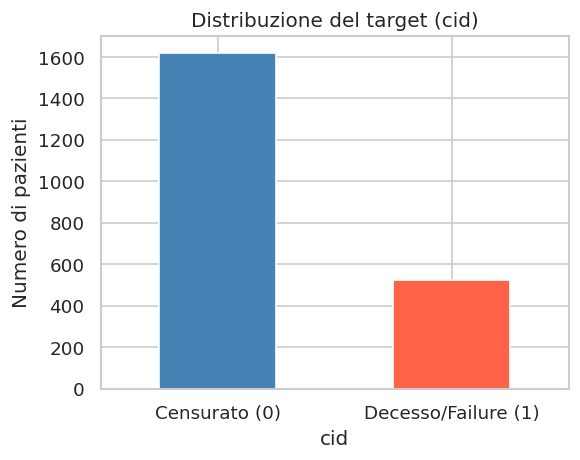

In [4]:
# Distribuzione del target
fig, ax = plt.subplots(figsize=(5, 4))
df['cid'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_xticklabels(['Censurato (0)', 'Decesso/Failure (1)'], rotation=0)
ax.set_title('Distribuzione del target (cid)')
ax.set_ylabel('Numero di pazienti')
plt.tight_layout()
plt.show()

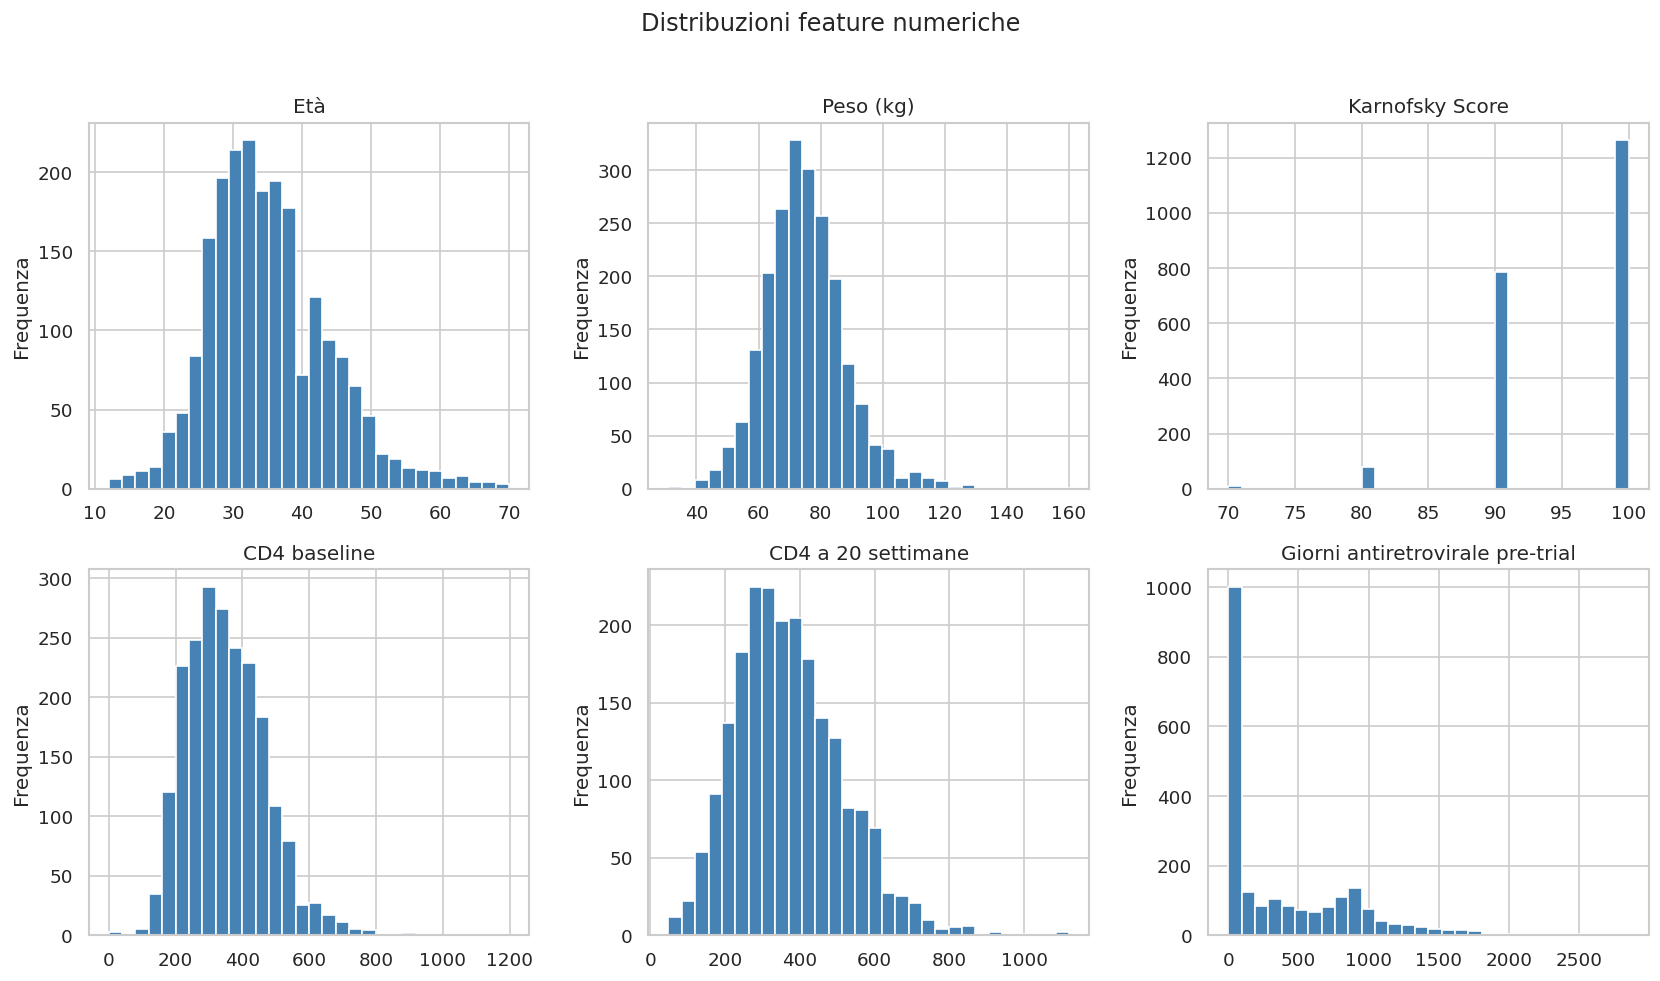

In [5]:
# Distribuzioni feature numeriche principali
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

features = ['age', 'wtkg', 'karnof', 'cd40', 'cd420', 'preanti']
titles = ['Età', 'Peso (kg)', 'Karnofsky Score', 'CD4 baseline', 'CD4 a 20 settimane', 'Giorni antiretrovirale pre-trial']

for ax, feat, title in zip(axes.flatten(), features, titles):
    df[feat].hist(ax=ax, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Frequenza')

plt.suptitle('Distribuzioni feature numeriche', y=1.02)
plt.tight_layout()
plt.show()


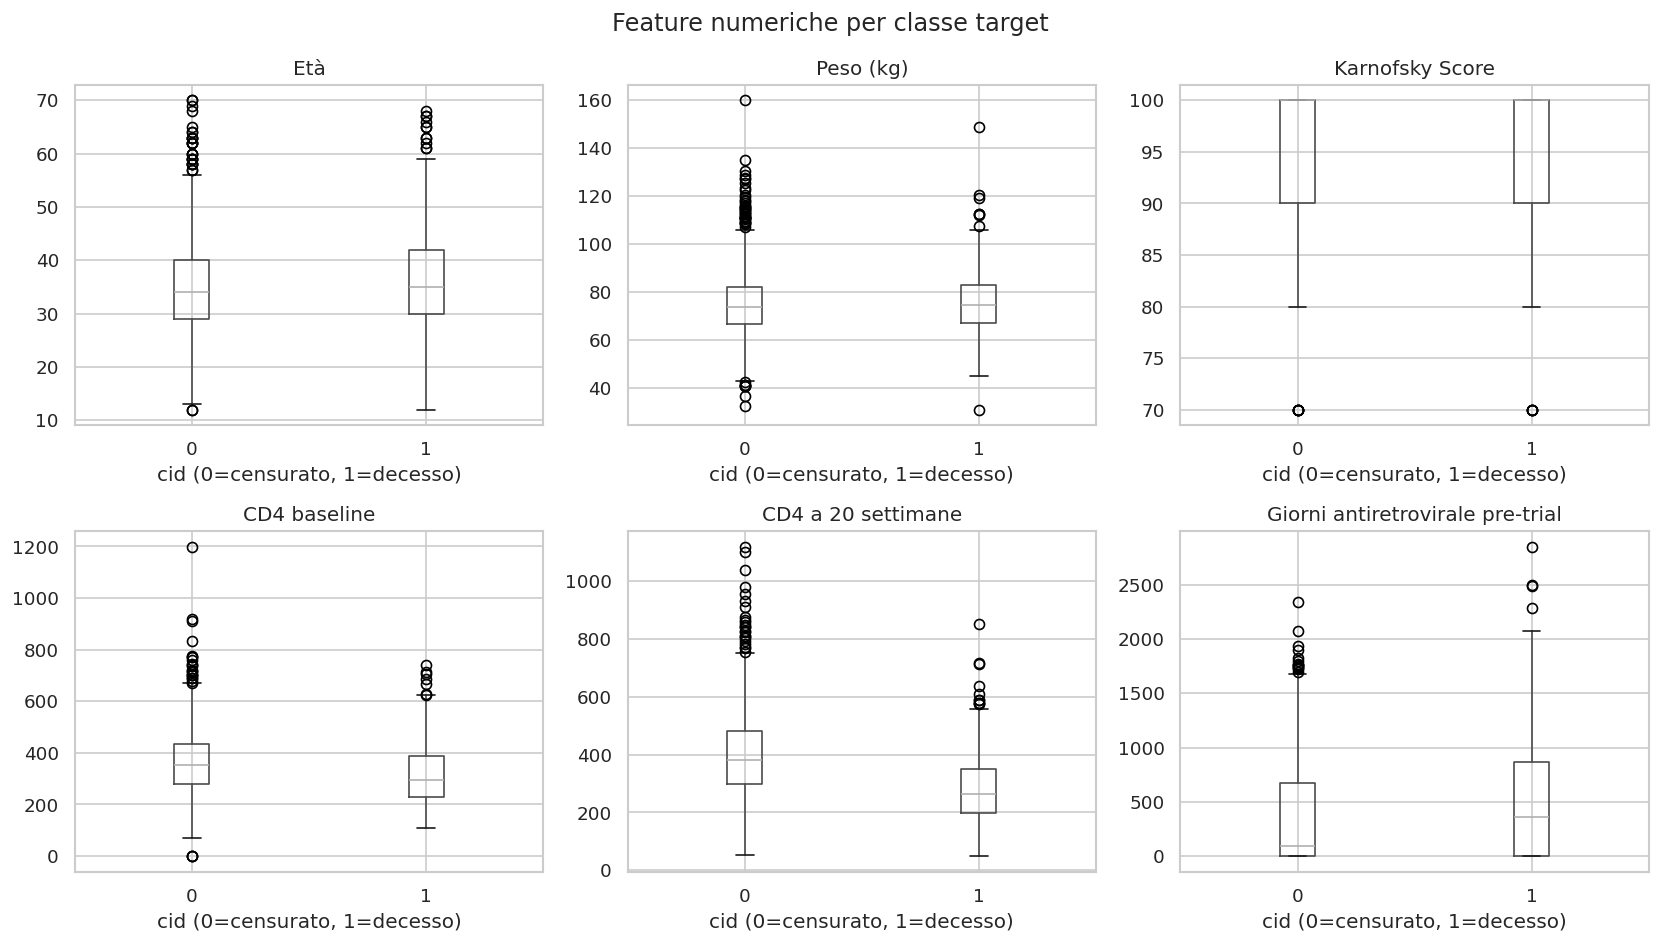

In [6]:
# Boxplot feature numeriche per classe target
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

features = ['age', 'wtkg', 'karnof', 'cd40', 'cd420', 'preanti']
titles = ['Età', 'Peso (kg)', 'Karnofsky Score', 'CD4 baseline', 'CD4 a 20 settimane', 'Giorni antiretrovirale pre-trial']

for ax, feat, title in zip(axes.flatten(), features, titles):
    df.boxplot(column=feat, by='cid', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('cid (0=censurato, 1=decesso)')
    ax.set_ylabel('')

plt.suptitle('Feature numeriche per classe target')
plt.tight_layout()
plt.show()

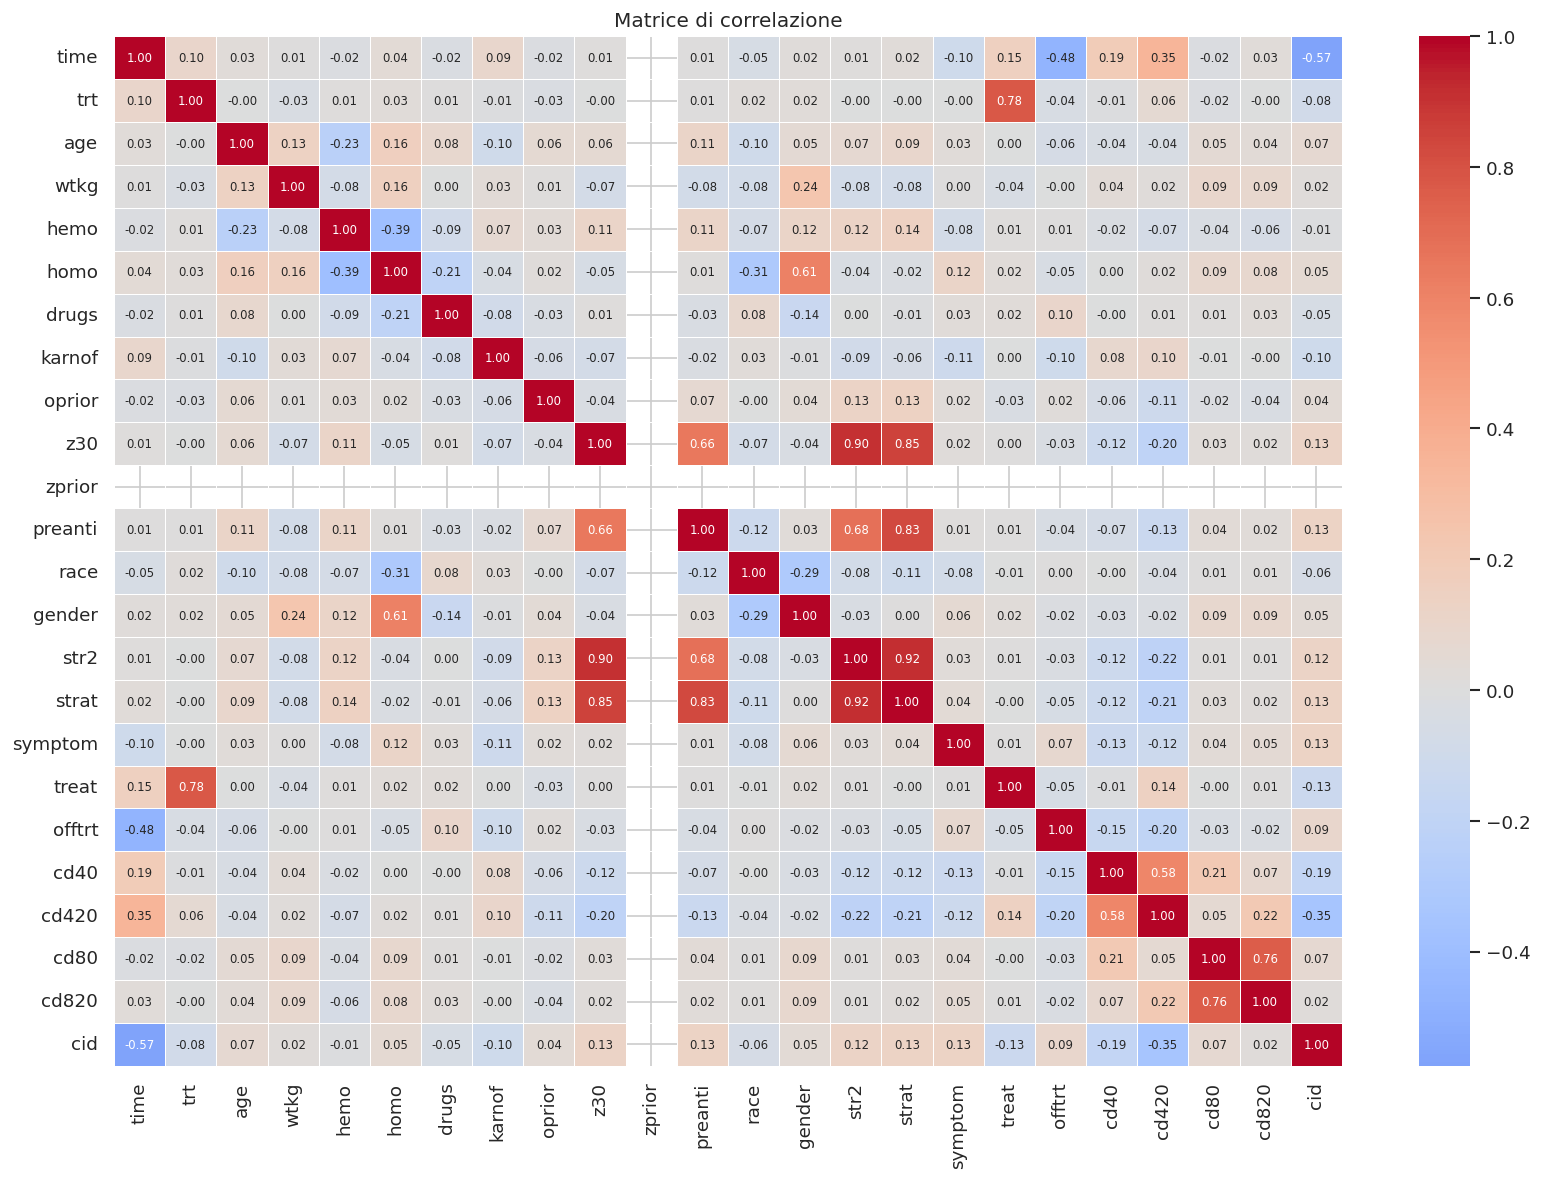

In [7]:
# ── Heatmap correlazioni ───────────────────────────────────────
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

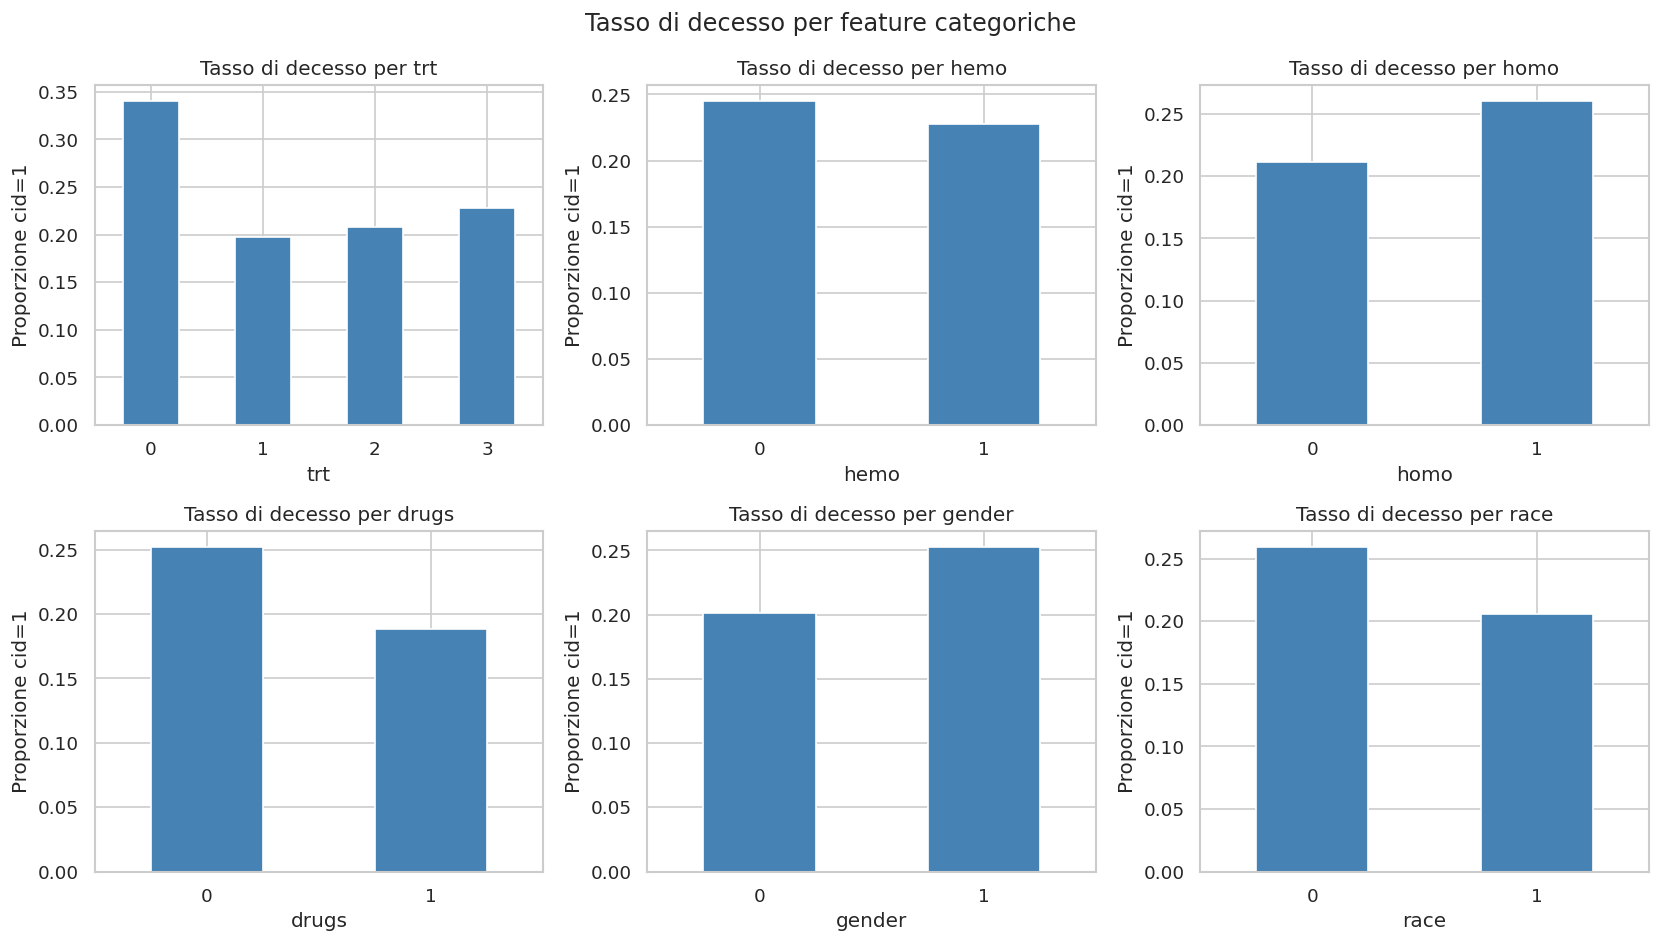

In [8]:
# Feature categoriche vs target
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

cat_features = ['trt', 'hemo', 'homo', 'drugs', 'gender', 'race']

for ax, feat in zip(axes.flatten(), cat_features):
    df.groupby(feat)['cid'].mean().plot(kind='bar', ax=ax,
                                         color='steelblue', edgecolor='white')
    ax.set_title(f'Tasso di decesso per {feat}')
    ax.set_ylabel('Proporzione cid=1')
    ax.set_xlabel(feat)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Tasso di decesso per feature categoriche')
plt.tight_layout()
plt.show()

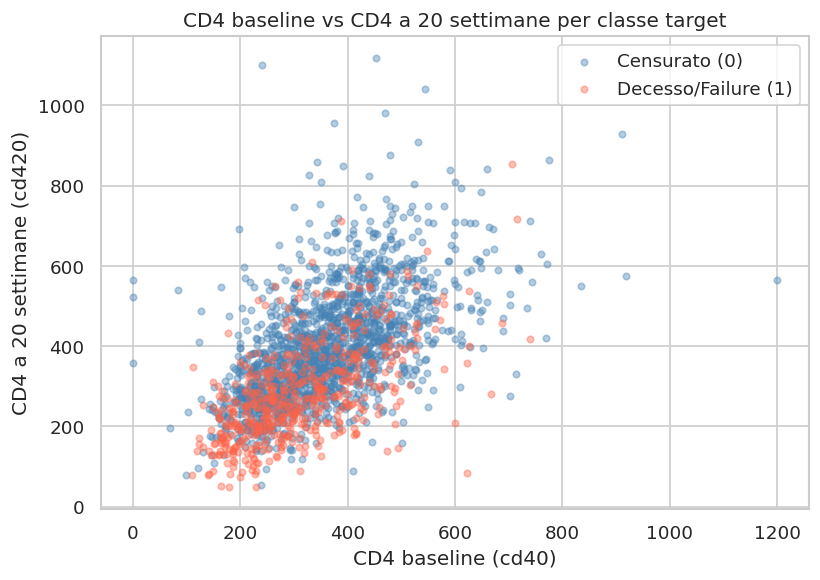

In [9]:
# Scatterplot cd40 vs cd420 per classe target
plt.figure(figsize=(7, 5))

for cid_val, color, label in zip([0, 1], ['steelblue', 'tomato'],
                                  ['Censurato (0)', 'Decesso/Failure (1)']):
    subset = df[df['cid'] == cid_val]
    plt.scatter(subset['cd40'], subset['cd420'],
                alpha=0.4, s=15, color=color, label=label)

plt.xlabel('CD4 baseline (cd40)')
plt.ylabel('CD4 a 20 settimane (cd420)')
plt.title('CD4 baseline vs CD4 a 20 settimane per classe target')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Preprocessing: rimozione feature problematiche
# Partiamo dal df già costruito nell'EDA
# Separiamo X e y
X = df.drop(columns=['cid'])
y = df['cid']

# Feature da rimuovere e motivazione:
# - zprior: varianza zero (sempre 1), nessuna informazione
# - time: leakage — codifica implicitamente l'outcome (giorni all'evento)
# - treat: ridondante con trt (è una sua versione binaria semplificata)
# - str2, z30: fortemente correlate con strat (r > 0.85), che è più informativa

cols_to_drop = ['zprior', 'time', 'treat', 'str2', 'z30']
X = X.drop(columns=cols_to_drop)

print(f"Feature rimanenti ({X.shape[1]}):\n{X.columns.tolist()}")

Feature rimanenti (18):
['trt', 'age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'preanti', 'race', 'gender', 'strat', 'symptom', 'offtrt', 'cd40', 'cd420', 'cd80', 'cd820']


In [11]:
# Encoding variabili categoriche

# trt ha 4 classi nominali (0,1,2,3): i valori non hanno ordine,
# quindi usiamo one-hot encoding.
# drop_first=True rimuove una colonna ridondante (dummy variable trap)

X = pd.get_dummies(X, columns=['trt'], drop_first=True)

print(f"Colonne dopo encoding:\n{X.columns.tolist()}")

Colonne dopo encoding:
['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'preanti', 'race', 'gender', 'strat', 'symptom', 'offtrt', 'cd40', 'cd420', 'cd80', 'cd820', 'trt_1', 'trt_2', 'trt_3']


In [12]:
# Train/test split

# stratify=y: mantiene la stessa proporzione di classi (75/25)
# in entrambi i set — importante con classi sbilanciate

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\nDistribuzione target nel train:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nDistribuzione target nel test:\n{y_test.value_counts(normalize=True).round(3)}")

Train: (1711, 20)  |  Test: (428, 20)

Distribuzione target nel train:
cid
0    0.756
1    0.244
Name: proportion, dtype: float64

Distribuzione target nel test:
cid
0    0.757
1    0.243
Name: proportion, dtype: float64


In [13]:
# Scaling feature numeriche

# StandardScaler porta ogni feature a media 0 e deviazione standard 1.
# Necessario per modelli come la Logistic Regression che sono sensibili
# alla scala delle feature.

# IMPORTANTE: fit solo su X_train, poi transform su entrambi.
# Fittare anche su X_test sarebbe data leakage.

from sklearn.preprocessing import StandardScaler

num_features = ['age', 'wtkg', 'karnof', 'preanti',
                'cd40', 'cd420', 'cd80', 'cd820']

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

In [14]:
# Converti colonne booleane in interi (0/1)
bool_cols = ['trt_1', 'trt_2', 'trt_3']
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [15]:
# Verifica

print("Shape finale:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"\nValori nulli in X_train: {X_train.isnull().sum().sum()}")
print(f"\nPrime righe X_train:")
X_train.head()

Shape finale:
  X_train: (1711, 20)
  X_test:  (428, 20)

Valori nulli in X_train: 0

Prime righe X_train:


,age,wtkg,hemo,homo,drugs,karnof,oprior,preanti,race,gender,strat,symptom,offtrt,cd40,cd420,cd80,cd820,trt_1,trt_2,trt_3
761,0.312286,0.179207,0,0,1,-0.916909,0,0.950824,1,0,3,0,1,0.036212,-0.219689,-1.018553,-0.719147,0,0,0
480,0.312286,-0.553580,0,1,0,0.773642,0,-0.810864,0,1,1,1,0,-1.478898,0.409997,0.525884,0.927983,1,0,0
58,-0.609753,0.237830,0,1,0,0.773642,0,-0.810864,0,1,1,0,0,0.315534,-0.123868,-0.696362,-1.206769,0,0,1
1803,-0.840263,-1.276171,0,1,0,0.773642,0,1.379925,1,1,3,0,0,1.669822,0.697462,-0.236981,-0.770830,0,0,1
248,1.580090,1.870837,0,1,0,-0.916909,0,2.423569,0,1,3,0,0,0.645642,-0.164934,-1.016475,-1.089920,0,0,0


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, f1_score)
import matplotlib.pyplot as plt
import pandas as pd


In [17]:
# Strategia di cross-validation: 5 fold, stratificata (mantiene proporzione classi)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definizione modelli
# - class_weight='balanced' disponibile solo per LogisticRegression tra i quattro
# - LDA usa i prior delle classi automaticamente
# - GaussianNB e MLPClassifier non supportano class_weight in sklearn
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'LDA': LinearDiscriminantAnalysis(),
    'Naive Bayes (Gaussian)': GaussianNB(),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(64, 32),  # 2 layer nascosti: 64 e 32 neuroni
        activation='relu',
        max_iter=2000,
        random_state=42
    )
}

In [18]:
# Metriche valutate in CV
scoring = ['f1', 'roc_auc', 'precision', 'recall']

cv_results = {}

for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    cv_results[name] = {
        'F1 (CV)':        scores['test_f1'].mean(),
        'AUC (CV)':       scores['test_roc_auc'].mean(),
        'Precision (CV)': scores['test_precision'].mean(),
        'Recall (CV)':    scores['test_recall'].mean(),
    }
    print(f"\n{name}")
    print(f"  F1:        {scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}")
    print(f"  AUC:       {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}")
    print(f"  Precision: {scores['test_precision'].mean():.3f}")
    print(f"  Recall:    {scores['test_recall'].mean():.3f}")


Logistic Regression
  F1:        0.512 ± 0.016
  AUC:       0.751 ± 0.026
  Precision: 0.403
  Recall:    0.703

LDA
  F1:        0.354 ± 0.037
  AUC:       0.747 ± 0.026
  Precision: 0.635
  Recall:    0.247

Naive Bayes (Gaussian)
  F1:        0.432 ± 0.044
  AUC:       0.711 ± 0.023
  Precision: 0.482
  Recall:    0.394

MLP
  F1:        0.365 ± 0.015
  AUC:       0.643 ± 0.014
  Precision: 0.395
  Recall:    0.340


In [19]:
test_results = {}

for name, model in models.items():
    # Fit sul training completo
    model.fit(X_train, y_train)

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred)

    test_results[name] = {
        'AUC (test)': round(auc, 3),
        'F1 (test)':  round(f1, 3),
    }

    print(f"\n{'='*40}")
    print(f"{name}")
    print(classification_report(y_test, y_pred, target_names=['Censurato (0)', 'Evento (1)']))
    print(f"AUC-ROC: {auc:.3f}")


Logistic Regression
               precision    recall  f1-score   support

Censurato (0)       0.90      0.69      0.78       324
   Evento (1)       0.44      0.75      0.55       104

     accuracy                           0.71       428
    macro avg       0.67      0.72      0.67       428
 weighted avg       0.78      0.71      0.73       428

AUC-ROC: 0.785

LDA
               precision    recall  f1-score   support

Censurato (0)       0.80      0.97      0.88       324
   Evento (1)       0.73      0.26      0.38       104

     accuracy                           0.80       428
    macro avg       0.77      0.61      0.63       428
 weighted avg       0.79      0.80      0.76       428

AUC-ROC: 0.782

Naive Bayes (Gaussian)
               precision    recall  f1-score   support

Censurato (0)       0.84      0.87      0.85       324
   Evento (1)       0.53      0.47      0.50       104

     accuracy                           0.77       428
    macro avg       0.68      0.

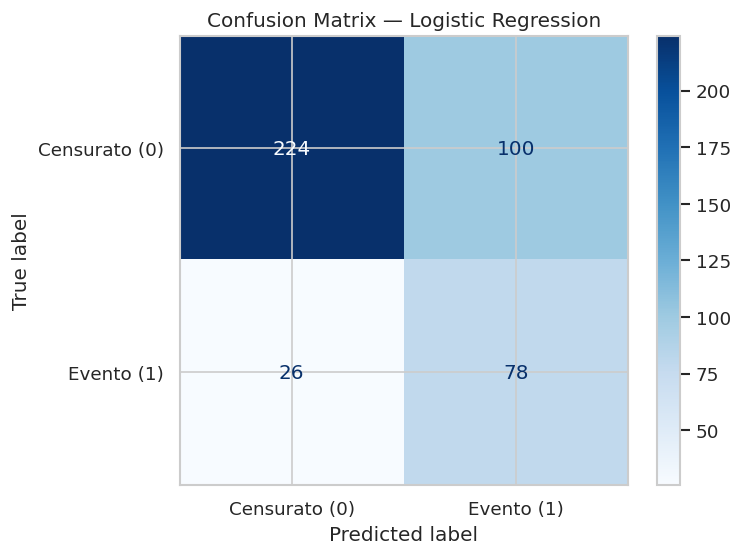

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = models['Logistic Regression']
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test,
    display_labels=['Censurato (0)', 'Evento (1)'], cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

In [20]:
# Unisce risultati CV e test in un'unica tabella
df_cv   = pd.DataFrame(cv_results).T.round(3)
df_test = pd.DataFrame(test_results).T.round(3)
df_final = pd.concat([df_cv, df_test], axis=1)

print(df_final.to_string())

                        F1 (CV)  AUC (CV)  Precision (CV)  Recall (CV)  AUC (test)  F1 (test)
Logistic Regression       0.512     0.751           0.403        0.703       0.785      0.553
LDA                       0.354     0.747           0.635        0.247       0.782      0.383
Naive Bayes (Gaussian)    0.432     0.711           0.482        0.394       0.762      0.500
MLP                       0.365     0.643           0.395        0.340       0.653      0.376


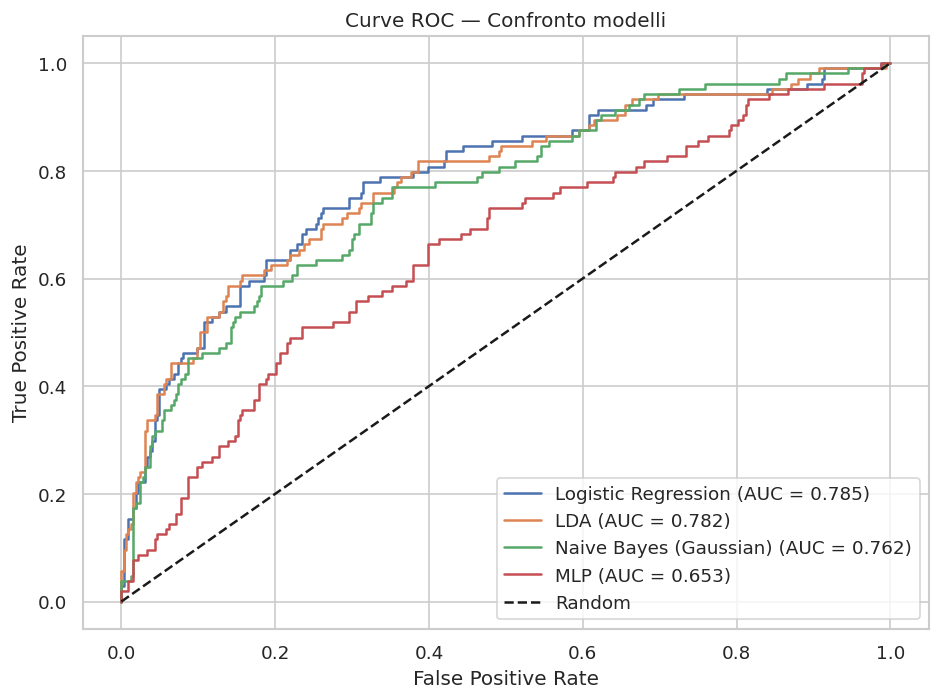

In [21]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curve ROC — Confronto modelli')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()